<a href="https://colab.research.google.com/github/sans0726/ds-genai-journey/blob/main/cnn2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train: (60000, 28, 28)
X_test: (10000, 28, 28)


In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [4]:
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(X_train.shape)

(60000, 28, 28, 1)


In [5]:
model = models.Sequential([

    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 26ms/step - accuracy: 0.9513 - loss: 0.1579 - val_accuracy: 0.9842 - val_loss: 0.0587
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 83s 27ms/step - accuracy: 0.9853 - loss: 0.0487 - val_accuracy: 0.9842 - val_loss: 0.0482
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9886 - loss: 0.0349 - val_accuracy: 0.9883 - val_loss: 0.0382
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 47s 28ms/step - accuracy: 0.9919 - loss: 0.0251 - val_accuracy: 0.9897 - val_loss: 0.0337
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 44s 26ms/step - accuracy: 0.9940 - loss: 0.0185 - val_accuracy: 0.9907 - val_loss: 0.0342


In [10]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9884 - loss: 0.0356
Test Accuracy: 0.9883999824523926


In [11]:
predictions = model.predict(X_test)

predicted_digit = np.argmax(predictions[0])

print("Actual:", y_test[0])
print("Predicted:", predicted_digit)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Actual: 7
Predicted: 7


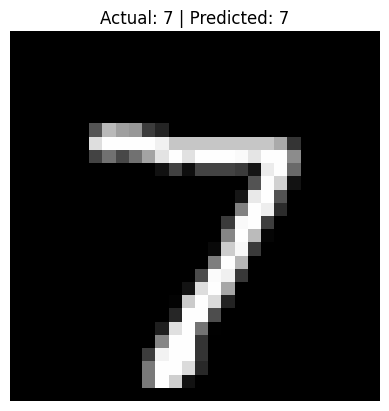

In [12]:
plt.imshow(X_test[0].squeeze(), cmap='gray')

plt.title(
    f"Actual: {y_test[0]} | Predicted: {predicted_digit}"
)

plt.axis('off')
plt.show()

In [13]:
feature_model = models.Model(
    inputs=model.inputs,
    outputs=[
        model.layers[0].output,
        model.layers[2].output
    ]
)

In [14]:
image = X_test[0:1]

In [15]:
feature_maps = feature_model.predict(image)

first_layer = feature_maps[0]
second_layer = feature_maps[1]

print("First convolution output:", first_layer.shape)
print("Second convolution output:", second_layer.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
First convolution output: (1, 26, 26, 32)
Second convolution output: (1, 11, 11, 64)


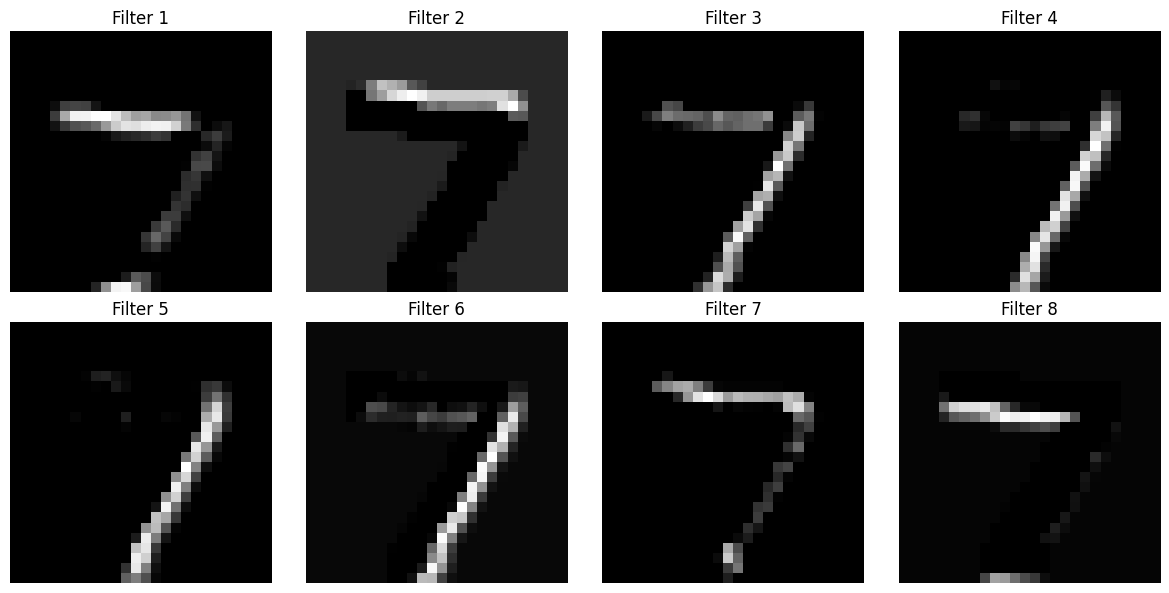

In [16]:
plt.figure(figsize=(12, 6))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        first_layer[0, :, :, i],
        cmap='gray'
    )

    plt.title(f"Filter {i + 1}")
    plt.axis('off')

plt.tight_layout()
plt.show()